In [2]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
import itertools
import copy
import polars as pl
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [3]:
# Local example
BASE_PATH = Path("/Users/shen/Documents/Research/kaggle/jane/train.parquet")

# Kaggle example
# BASE_PATH = Path("/kaggle/input/jane-street-real-time-market-data-forecasting/train.parquet")

FEATURE_COLS = [f"feature_{i:02d}" for i in range(79)]
TARGET_COL = "responder_6"
WEIGHT_COL = "weight"
DATE_COL = "date_id"
TIME_COL = "time_id"
SYMBOL_COL = "symbol_id"

# Default tuning / backtest settings
DEFAULT_TUNE_SAMPLE_FRAC = 0.35
DEFAULT_PRED_CLIP = None   # example: (-5, 5)
DEFAULT_RANDOM_SEED = 42

In [4]:
def load_partitions(partition_ids, base_path=BASE_PATH, sample_frac=0.2, seed=42, group_cols=[DATE_COL]):
    dfs = []

    for pid in partition_ids:
        part_path = base_path / f"partition_id={pid}" / "part-0.parquet"
        df = pl.read_parquet(part_path)

        if sample_frac is not None and sample_frac < 1.0:
            df = sample_train_by_group(
                df,
                sample_frac=sample_frac,
                group_cols=group_cols,
                seed=seed + int(pid),
            )

        dfs.append(df)

    df_all = pl.concat(dfs, how="vertical_relaxed")
    return df_all

def prepare_xywd(
    df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    weight_col=WEIGHT_COL,
    date_col=DATE_COL,
):

    df = df.filter(pl.col(target_col).is_not_null())
    numeric_exprs = [pl.col(c).cast(pl.Float32).fill_null(float("nan")).alias(c) for c in feature_cols]
    X = df.select(numeric_exprs)
    y = df.get_column(target_col).cast(pl.Float32).to_numpy()
    w = df.get_column(weight_col).fill_null(0.0).cast(pl.Float32).to_numpy()
    d = df.get_column(date_col).to_numpy()

    return X, y, w, d

def official_weighted_r2(y_true, y_pred, sample_weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = np.asarray(sample_weight, dtype=float)

    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * y_true ** 2)

    return 1.0 - ss_res / ss_tot

def sample_train_by_group(df, sample_frac=0.2, group_cols=["date_id", "time_id"], seed=42):

    if sample_frac >= 1.0 or sample_frac is None:
        return df

    is_polars = isinstance(df, pl.DataFrame)
    if is_polars:
        pdf = df.to_pandas()
    else:
        pdf = df.copy()

    rng = np.random.default_rng(seed)
    pdf['__rand__'] = rng.random(len(pdf))

    group_sizes = pdf.groupby(group_cols)['__rand__'].transform('size')
    target_n = np.maximum(1, np.floor(group_sizes * sample_frac))

    pdf['__rank__'] = pdf.groupby(group_cols)['__rand__'].rank(method='first')
    sampled_pdf = pdf[pdf['__rank__'] <= target_n].drop(columns=['__rand__', '__rank__'])

    if is_polars:
        return pl.from_pandas(sampled_pdf)
    else:
        return sampled_pdf

In [5]:
def build_time_decay_weights(date_ids, min_multiplier=0.5, max_multiplier=1.5):
    min_date = date_ids.min()
    max_date = date_ids.max()
    if max_date == min_date:
        return np.ones_like(date_ids, dtype=float)
    
    ratio = (date_ids - min_date) / (max_date - min_date)
    w_time = min_multiplier + ratio * (max_multiplier - min_multiplier)
    return w_time

In [6]:
def expanding_window_lgbm_backtest(
    start_val_partition=1,
    end_val_partition=8,
    train_sample_frac=0.1,
    use_time_decay=True,
    lgb_params=None,
    seed=42,
    time_weight_min=0.5,
    time_weight_max=1.5,
):
    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 63,
            "max_depth": 6,
            "min_data_in_leaf": 1000,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 300,
            "n_jobs": -1,
        }

    records = []

    for val_pid in tqdm(
    range(start_val_partition, end_val_partition + 1),
    desc="Backtest folds",
    leave=False
):
        train_pids = list(range(val_pid))

        print("\n" + "=" * 80)
        print(f"LGBM - Train partitions: {train_pids}")
        print(f"LGBM - Validation partition: {val_pid}")

        train_df = load_partitions(
            train_pids,
            sample_frac=train_sample_frac,
            seed=seed,
        )

        val_df = load_partitions(
            [val_pid],
            sample_frac=1.0,
            seed=seed,
        )

        X_train, y_train, w_train_base, d_train = prepare_xywd(train_df)
        X_val, y_val, w_val, d_val = prepare_xywd(val_df)

        if use_time_decay:
            w_time = build_time_decay_weights(d_train, min_multiplier=time_weight_min, max_multiplier=time_weight_max)
            w_train = w_train_base * w_time
        else:
            w_train = w_train_base

        print("Training LightGBM ...")
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X_train, y_train, sample_weight=w_train)

        pred_train = model.predict(X_train)
        pred_val = model.predict(X_val)

        train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
        val_r2 = official_weighted_r2(y_val, pred_val, w_val)

        records.append(
            {
                "val_partition": val_pid,
                "train_rows": len(y_train),
                "val_rows": len(y_val),
                "train_official_r2": train_r2,
                "val_official_r2": val_r2,
            }
        )

        print(
            f"LGBM train_r2={train_r2:.6f} "
            f"val_r2={val_r2:.6f} "
        )

        del train_df, val_df, X_train, y_train, w_train_base, d_train, w_train
        del X_val, y_val, w_val, d_val, pred_train, pred_val, model
        gc.collect()

    return pd.DataFrame(records)

In [7]:
def tune_lgbm_holdout(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.1,
    use_time_decay=True,
    lgb_params=None,
    seed=42,
):
    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 63,
            "max_depth": 6,
            "min_data_in_leaf": 1000,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 300,
            "n_jobs": -1,
        }

    print("\n" + "=" * 80)
    print(f"Tuning holdout - Train partitions: {list(train_partitions)}")
    print(f"Tuning holdout - Validation partition: {val_partition}")

    # train: 0..8
    train_df = load_partitions(
        train_partitions,
        sample_frac=train_sample_frac,
        seed=seed,
    )

    # val: 9 (full)
    val_df = load_partitions(
        [val_partition],
        sample_frac=1.0,
        seed=seed,
    )

    X_train, y_train, w_train_base, d_train = prepare_xywd(train_df)
    X_val, y_val, w_val, d_val = prepare_xywd(val_df)

    if use_time_decay:
        w_time = build_time_decay_weights(
            d_train,
            min_multiplier=0.5,
            max_multiplier=1.5,
        )
        w_train = w_train_base * w_time
    else:
        w_train = w_train_base

    print("Training LightGBM for holdout tuning ...")
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, sample_weight=w_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
    val_r2 = official_weighted_r2(y_val, pred_val, w_val)

    print(
        f"Holdout train_r2={train_r2:.6f} "
        f"holdout val_r2={val_r2:.6f}"
    )

    result = {
        "train_rows": len(y_train),
        "val_rows": len(y_val),
        "train_official_r2": train_r2,
        "val_official_r2": val_r2,
    }

    del train_df, val_df, X_train, y_train, w_train_base, d_train, w_train
    del X_val, y_val, w_val, d_val, pred_train, pred_val, model
    gc.collect()

    return result

In [8]:
def tune_lgbm_holdout_es(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.1,
    val_sample_frac=0.2,
    use_time_decay=True,
    lgb_params=None,
    seed=42,
    huge_n_estimators=10000,
    early_stopping_rounds=50,
    time_weight_min=0.5,
    time_weight_max=1.5,
):
    """
    Holdout tuning with early stopping:
    - train on partitions 0..8
    - validate on partition 9
    - huge n_estimators + early stopping
    """

    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 63,
            "max_depth": 6,
            "min_data_in_leaf": 1000,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": huge_n_estimators,
            "n_jobs": -1,
        }

    print("\n" + "=" * 80)
    print(f"Tuning holdout - Train partitions: {list(train_partitions)}")
    print(f"Tuning holdout - Validation partition: {val_partition}")

    # 1. load data
    train_df = load_partitions(
        train_partitions,
        sample_frac=train_sample_frac,
        seed=seed,
    )

    val_df = load_partitions(
        [val_partition],
        sample_frac=val_sample_frac,
        seed=seed,
    )

    # 2. prepare data
    X_train, y_train, w_train_base, d_train = prepare_xywd(train_df)
    X_val, y_val, w_val, d_val = prepare_xywd(val_df)

    # 3. training weights
    if use_time_decay:
        w_time = build_time_decay_weights(
            d_train,
            min_multiplier=time_weight_min,
            max_multiplier=time_weight_max,
        )
        w_train = w_train_base * w_time
    else:
        w_train = w_train_base

    # 4. params
    params = copy.deepcopy(lgb_params)
    params["n_estimators"] = huge_n_estimators

    print(
        f"Training LightGBM with early stopping: "
        f"n_estimators={huge_n_estimators}, "
        f"early_stopping_rounds={early_stopping_rounds}"
    )

    # 5. fit with early stopping
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        eval_sample_weight=[w_val],
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=early_stopping_rounds,
                first_metric_only=True,
                verbose=False,
            ),
        ],
    )

    # 6. get best iteration
    best_iteration = getattr(model, "best_iteration_", None)
    if best_iteration is None or best_iteration <= 0:
        best_iteration = huge_n_estimators

    # 7. predict using best iteration
    pred_train = model.predict(X_train, num_iteration=best_iteration)
    pred_val = model.predict(X_val, num_iteration=best_iteration)

    # 8. evaluate
    train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
    val_r2 = official_weighted_r2(y_val, pred_val, w_val)

    print(
        f"Holdout best_iteration={best_iteration} "
        f"train_r2={train_r2:.6f} "
        f"val_r2={val_r2:.6f}"
    )

    result = {
        "train_rows": len(y_train),
        "val_rows": len(y_val),
        "best_iteration": int(best_iteration),
        "train_official_r2": train_r2,
        "val_official_r2": val_r2,
    }

    del train_df, val_df, X_train, X_val
    del y_train, y_val, w_train_base, w_val, d_train, d_val
    del w_train, pred_train, pred_val, model
    gc.collect()

    return result

In [8]:
# ===== Step 1: tune tree complexity using holdout + early stopping =====
max_depth_list = [5, 6, 7]                   
num_leaves_list = [31, 47, 63, 90]        
min_data_in_leaf_list = [500, 800, 2000]

base_lgb_params = {
    "objective": "regression",
    "metric": "l2",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 6,
    "min_data_in_leaf": 1000,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l2": 5.0,
    "verbosity": -1,
    "random_state": DEFAULT_RANDOM_SEED,
    "n_estimators": 10000,   
    "n_jobs": -1,
}

stage1_records = []

for num_leaves, max_depth, min_data_in_leaf in tqdm(
    itertools.product(num_leaves_list, max_depth_list, min_data_in_leaf_list),
    desc="Stage 1 tuning (ES)"
):
    if num_leaves >= 2 ** max_depth:
        print("\n" + "-" * 100)
        print(
            f"Skipping params: num_leaves={num_leaves} "
            f"is too large for max_depth={max_depth}"
        )
        continue

    current_params = copy.deepcopy(base_lgb_params)
    current_params["num_leaves"] = num_leaves
    current_params["max_depth"] = max_depth
    current_params["min_data_in_leaf"] = min_data_in_leaf

    print("\n" + "=" * 100)
    print(
        f"Trying params: "
        f"num_leaves={num_leaves}, "
        f"max_depth={max_depth}, "
        f"min_data_in_leaf={min_data_in_leaf}"
    )

    result = tune_lgbm_holdout_es(
        train_partitions=range(0, 9),   # 0..8
        val_partition=9,                # 9
        train_sample_frac=0.02,
        val_sample_frac=0.1,
        use_time_decay=True,
        lgb_params=current_params,
        seed=DEFAULT_RANDOM_SEED,
        huge_n_estimators=10000,
        early_stopping_rounds=50,
    )

    stage1_records.append(
        {
            "num_leaves": num_leaves,
            "max_depth": max_depth,
            "min_data_in_leaf": min_data_in_leaf,
            "train_rows": result["train_rows"],
            "val_rows": result["val_rows"],
            "best_iteration": result["best_iteration"],
            "train_official_r2": result["train_official_r2"],
            "val_official_r2": result["val_official_r2"],
        }
    )

    print(f"Holdout best_iteration: {result['best_iteration']}")
    print(f"Holdout train official R2: {result['train_official_r2']:.6f}")
    print(f"Holdout validation official R2: {result['val_official_r2']:.6f}")

stage1_df = (
    pd.DataFrame(stage1_records)
    .sort_values("val_official_r2", ascending=False)
    .reset_index(drop=True)
)

display(stage1_df)
print("\nBest parameter combination in step 1:")
display(stage1_df.head(1))

Stage 1 tuning (ES): 0it [00:00, ?it/s]


Trying params: num_leaves=31, max_depth=5, min_data_in_leaf=500

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=277 train_r2=0.031493 val_r2=0.006253
Holdout best_iteration: 277
Holdout train official R2: 0.031493
Holdout validation official R2: 0.006253

Trying params: num_leaves=31, max_depth=5, min_data_in_leaf=800

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=307 train_r2=0.029639 val_r2=0.005687
Holdout best_iteration: 307
Holdout train official R2: 0.029639
Holdout validation official R2: 0.005687

Trying params: num_leaves=31, max_depth=5, min_data_in_leaf=2000

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation pa

,num_leaves,max_depth,min_data_in_leaf,train_rows,val_rows,best_iteration,train_official_r2,val_official_r2
0,31,5,500,816349,627409,277,0.031493,0.006253
1,90,7,500,816349,627409,156,0.035195,0.006212
2,63,7,500,816349,627409,156,0.035085,0.006175
3,47,7,800,816349,627409,214,0.035326,0.006124
4,47,6,500,816349,627409,167,0.030073,0.006112
5,31,6,500,816349,627409,190,0.030758,0.006105
6,31,7,500,816349,627409,168,0.031071,0.006095
7,63,6,500,816349,627409,168,0.030152,0.006035
8,31,6,800,816349,627409,167,0.025736,0.005898
9,47,7,500,816349,627409,167,0.035233,0.005890



Best parameter combination in step 1:


,num_leaves,max_depth,min_data_in_leaf,train_rows,val_rows,best_iteration,train_official_r2,val_official_r2
0,31,5,500,816349,627409,277,0.031493,0.006253


In [16]:
# ===== Step 2: tune sampling and regularization with early stopping =====
feature_fraction_list = [0.6, 0.8, 1.0]
bagging_fraction_list = [0.6, 0.8, 1.0]
lambda_l2_list = [0.0, 2.0, 5.0, 10.0]

base_lgb_params = {
    "objective": "regression",
    "metric": "l2",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,          # Step 1 best
    "max_depth": 5,            # Step 1 best
    "min_data_in_leaf": 500,   # Step 1 best
    "bagging_freq": 1,         
    "verbosity": -1,
    "random_state": DEFAULT_RANDOM_SEED,
    "n_estimators": 10000,     
    "n_jobs": -1,
}

stage2_records = []

for ff, bf, l2 in tqdm(
    itertools.product(feature_fraction_list, bagging_fraction_list, lambda_l2_list),
    desc="Stage 2 tuning (ES)"
):
    current_params = copy.deepcopy(base_lgb_params)
    current_params["feature_fraction"] = ff
    current_params["bagging_fraction"] = bf
    current_params["lambda_l2"] = l2

    print("\n" + "=" * 100)
    print(
        f"Trying params: "
        f"feature_fraction={ff}, "
        f"bagging_fraction={bf}, "
        f"lambda_l2={l2}"
    )

    result = tune_lgbm_holdout_es(
        train_partitions=range(0, 9),   # 0..8
        val_partition=9,                # 9
        train_sample_frac=0.02,
        val_sample_frac=0.1,
        use_time_decay=True,
        lgb_params=current_params,
        seed=DEFAULT_RANDOM_SEED,
        huge_n_estimators=10000,
        early_stopping_rounds=50,
    )

    stage2_records.append(
        {
            "feature_fraction": ff,
            "bagging_fraction": bf,
            "lambda_l2": l2,
            "train_rows": result["train_rows"],
            "val_rows": result["val_rows"],
            "best_iteration": result["best_iteration"],
            "train_official_r2": result["train_official_r2"],
            "val_official_r2": result["val_official_r2"],
        }
    )

    print(f"Holdout best_iteration: {result['best_iteration']}")
    print(f"Holdout train official R2: {result['train_official_r2']:.6f}")
    print(f"Holdout validation official R2: {result['val_official_r2']:.6f}")

stage2_df = (
    pd.DataFrame(stage2_records)
    .sort_values("val_official_r2", ascending=False)
    .reset_index(drop=True)
)

print("\nBest parameter combination in step 2:")
display(stage2_df.head(5))

Stage 2 tuning (ES): 0it [00:00, ?it/s]


Trying params: feature_fraction=0.6, bagging_fraction=0.6, lambda_l2=0.0

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=230 train_r2=0.026861 val_r2=0.005664
Holdout best_iteration: 230
Holdout train official R2: 0.026861
Holdout validation official R2: 0.005664

Trying params: feature_fraction=0.6, bagging_fraction=0.6, lambda_l2=2.0

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=245 train_r2=0.027915 val_r2=0.005633
Holdout best_iteration: 245
Holdout train official R2: 0.027915
Holdout validation official R2: 0.005633

Trying params: feature_fraction=0.6, bagging_fraction=0.6, lambda_l2=5.0

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuni

,feature_fraction,bagging_fraction,lambda_l2,train_rows,val_rows,best_iteration,train_official_r2,val_official_r2
0,0.6,1.0,5.0,816349,627409,232,0.029382,0.006633
1,0.6,1.0,10.0,816349,627409,341,0.036561,0.006559
2,0.8,1.0,10.0,816349,627409,267,0.031954,0.006400
3,0.6,0.8,0.0,816349,627409,292,0.031763,0.006363
4,1.0,1.0,5.0,816349,627409,305,0.034811,0.006348


In [ ]:
# ===== Step 3: tune learning_rate only, using early stopping =====

learning_rate_list = [0.01, 0.015, 0.02, 0.025, 0.03, 0.05]

base_lgb_params = {
    "objective": "regression",
    "metric": "l2",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,     
    "num_leaves": 31,          # Step 1 best
    "max_depth": 5,            # Step 1 best
    "min_data_in_leaf": 500,   # Step 1 best
    "feature_fraction": 0.6,   # Step 2 best
    "bagging_fraction": 1.0,   # Step 2 best
    "bagging_freq": 1,
    "lambda_l2": 5.0,          # Step 2 best
    "verbosity": -1,
    "random_state": DEFAULT_RANDOM_SEED,
    "n_estimators": 10000,      
    "n_jobs": -1,
}

stage3_records = []

for lr in tqdm(learning_rate_list, desc="Stage 3 tuning (learning_rate only)"):
    current_params = copy.deepcopy(base_lgb_params)
    current_params["learning_rate"] = lr

    print("\n" + "=" * 100)
    print(f"Trying params: learning_rate={lr}")

    result = tune_lgbm_holdout_es(
        train_partitions=range(0, 9),   # 0..8
        val_partition=9,                # 9
        train_sample_frac=0.02, 
        val_sample_frac=0.1,        
        use_time_decay=True,
        lgb_params=current_params,
        seed=DEFAULT_RANDOM_SEED,
        huge_n_estimators=10000,
        early_stopping_rounds=50,
    )

    stage3_records.append(
        {
            "learning_rate": lr,
            "train_rows": result["train_rows"],
            "val_rows": result["val_rows"],
            "best_iteration": result["best_iteration"],
            "train_official_r2": result["train_official_r2"],
            "val_official_r2": result["val_official_r2"],
        }
    )

    print(f"Holdout best_iteration: {result['best_iteration']}")
    print(f"Holdout train official R2: {result['train_official_r2']:.6f}")
    print(f"Holdout validation official R2: {result['val_official_r2']:.6f}")

stage3_df = (
    pd.DataFrame(stage3_records)
    .sort_values("val_official_r2", ascending=False)
    .reset_index(drop=True)
)

display(stage3_df)


Stage 3 tuning (learning_rate only):   0%|          | 0/6 [00:00<?, ?it/s]


Trying params: learning_rate=0.01

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=1198 train_r2=0.029910 val_r2=0.006411
Holdout best_iteration: 1198
Holdout train official R2: 0.029910
Holdout validation official R2: 0.006411

Trying params: learning_rate=0.015

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rounds=50
Holdout best_iteration=820 train_r2=0.030279 val_r2=0.006554
Holdout best_iteration: 820
Holdout train official R2: 0.030279
Holdout validation official R2: 0.006554

Trying params: learning_rate=0.02

Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM with early stopping: n_estimators=10000, early_stopping_rou

,learning_rate,train_rows,val_rows,best_iteration,train_official_r2,val_official_r2
0,0.050,816349,627409,232,0.029382,0.006633
1,0.020,816349,627409,640,0.031021,0.006580
2,0.015,816349,627409,820,0.030279,0.006554
3,0.025,816349,627409,602,0.033971,0.006522
4,0.010,816349,627409,1198,0.029910,0.006411
5,0.030,816349,627409,323,0.026671,0.006163


In [9]:
def dynamic_min_data_in_leaf_from_rows(
    current_rows,
    reference_rows,
    base_min_data_in_leaf=800,
    min_min_data_in_leaf=100,
):

    ratio = current_rows / reference_rows
    ratio_sqrt = np.sqrt(ratio)

    min_data_in_leaf_used = int(round(base_min_data_in_leaf * ratio_sqrt))
    min_data_in_leaf_used = max(min_min_data_in_leaf, min_data_in_leaf_used)

    return min_data_in_leaf_used

In [10]:
def expanding_window_lgbm_backtest_dynamic_min_data(
    reference_rows,
    start_train_partition=1,
    start_val_partition=2,
    end_val_partition=9,
    train_sample_frac=0.3,
    val_sample_frac=0.1,
    use_time_decay=True,
    base_lgb_params=None,
    seed=42,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
):
    """
    Expanding-window LightGBM backtest:
    - train: [start_train_partition, ..., val_pid-1]
    - validate: [val_pid]
    - no early stopping
    - ONLY dynamically adjust min_data_in_leaf
    - all other parameters remain fixed
    """

    if base_lgb_params is None:
        base_lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 31,          
            "max_depth": 5,            
            "min_data_in_leaf": 500,   
            "feature_fraction": 0.6,
            "bagging_fraction": 1.0,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 232,   
            "n_jobs": -1,
        }

    records = []

    for val_pid in tqdm(
        range(start_val_partition, end_val_partition + 1),
        desc="Dynamic min_data_in_leaf backtest",
        leave=False,
    ):
        train_pids = list(range(start_train_partition, val_pid))

        print("\n" + "=" * 100)
        print(f"Train partitions: {train_pids}")
        print(f"Validation partition: {val_pid}")

        # 1) load data
        train_df = load_partitions(
            train_pids,
            sample_frac=train_sample_frac,
            seed=seed,
        )

        val_df = load_partitions(
            [val_pid],
            sample_frac=val_sample_frac,
            seed=seed,
        )

        X_train, y_train, w_train_base, d_train = prepare_xywd(train_df)
        X_val, y_val, w_val, d_val = prepare_xywd(val_df)

        current_rows = len(y_train)

        min_data_in_leaf_used = dynamic_min_data_in_leaf_from_rows(
            current_rows=current_rows,
            reference_rows=reference_rows,
            base_min_data_in_leaf=base_lgb_params["min_data_in_leaf"],
            min_min_data_in_leaf=min_min_data_in_leaf,
        )

        params_fold = copy.deepcopy(base_lgb_params)
        params_fold["min_data_in_leaf"] = min_data_in_leaf_used

        if use_time_decay:
            w_time = build_time_decay_weights(
                d_train,
                min_multiplier=time_weight_min,
                max_multiplier=time_weight_max,
            )
            w_train = w_train_base * w_time
        else:
            w_train = w_train_base

        print(
            "Training LightGBM with dynamic min_data_in_leaf: "
            f"num_leaves={params_fold['num_leaves']}, "
            f"max_depth={params_fold['max_depth']}, "
            f"min_data_in_leaf={params_fold['min_data_in_leaf']}, "
            f"n_estimators={params_fold['n_estimators']}, "
            f"learning_rate={params_fold['learning_rate']}"
        )

        # 5) fit
        model = lgb.LGBMRegressor(**params_fold)
        model.fit(X_train, y_train, sample_weight=w_train)

        # 6) predict
        pred_train = model.predict(X_train)
        pred_val = model.predict(X_val)

        # 7) evaluate
        train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
        val_r2 = official_weighted_r2(y_val, pred_val, w_val)

        records.append(
            {
                "train_partitions": str(train_pids),
                "val_partition": val_pid,
                "train_rows": current_rows,
                "val_rows": len(y_val),
                "num_leaves_used": params_fold["num_leaves"],                  
                "min_data_in_leaf_used": params_fold["min_data_in_leaf"],      
                "n_estimators_used": params_fold["n_estimators"],              
                "learning_rate_used": params_fold["learning_rate"],            
                "train_official_r2": train_r2,
                "val_official_r2": val_r2,
                "train_sample_frac": train_sample_frac,
            }
        )

        print(
            f"Fold {val_pid}: "
            f"train_r2={train_r2:.6f}, "
            f"val_r2={val_r2:.6f}"
        )

        del train_df, val_df, X_train, X_val, y_train, y_val
        del w_train_base, w_val, d_train, d_val, w_train
        del pred_train, pred_val, model
        gc.collect()

    return pd.DataFrame(records)

In [ ]:
# 0.2

In [ ]:
# final_lgb_params = {
#     "objective": "regression",
#     "metric": "l2",
#     "boosting_type": "gbdt",
#     "learning_rate": 0.05,     
#     "num_leaves": 31,          
#     "max_depth": 5,            
#     "min_data_in_leaf": 500,   
#     "feature_fraction": 0.6,
#     "bagging_fraction": 1.0,
#     "bagging_freq": 1,
#     "lambda_l2": 5.0,
#     "verbosity": -1,
#     "random_state": DEFAULT_RANDOM_SEED,
#     "n_estimators": 232,       
#     "n_jobs": -1,
# }

# backtest_dynamic_min_df = expanding_window_lgbm_backtest_dynamic_min_data(
#     reference_rows=816349,
#     start_train_partition=0,
#     start_val_partition=1,
#     end_val_partition=9,
#     train_sample_frac=0.2,
#     val_sample_frac=1.0,
#     use_time_decay=True,
#     base_lgb_params=final_lgb_params,
#     seed=DEFAULT_RANDOM_SEED,
#     time_weight_min=0.5,
#     time_weight_max=1.5,
#     min_min_data_in_leaf=100,
# )

# display(backtest_dynamic_min_df)
# print("Mean train official R2:", backtest_dynamic_min_df["train_official_r2"].mean())
# print("Mean validation official R2:", backtest_dynamic_min_df["val_official_r2"].mean())

Dynamic min_data_in_leaf backtest:   0%|          | 0/8 [00:00<?, ?it/s]


Train partitions: [1]
Validation partition: 2
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=414, n_estimators=232, learning_rate=0.05
Fold 2: train_r2=0.046983, val_r2=0.009630

Train partitions: [1, 2]
Validation partition: 3
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=598, n_estimators=232, learning_rate=0.05
Fold 3: train_r2=0.033306, val_r2=0.009044

Train partitions: [1, 2, 3]
Validation partition: 4
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=777, n_estimators=232, learning_rate=0.05
Fold 4: train_r2=0.026502, val_r2=0.015124

Train partitions: [1, 2, 3, 4]
Validation partition: 5
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=955, n_estimators=232, learning_rate=0.05
Fold 5: train_r2=0.026550, val_r2=0.012919

Train partitions: [1, 2, 3, 4, 5]
Validation partition: 6
Training LightGBM w

,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,[1],2,560831,3036873,31,414,232,0.05,0.046983,0.009630,0.2
1,"[1, 2]",3,1168189,4016784,31,598,232,0.05,0.033306,0.009044,0.2
2,"[1, 2, 3]",4,1971472,5022952,31,777,232,0.05,0.026502,0.015124,0.2
3,"[1, 2, 3, 4]",5,2976008,5348200,31,955,232,0.05,0.026550,0.012919,0.2
4,"[1, 2, 3, 4, 5]",6,4045578,6203912,31,1113,232,0.05,0.024182,0.010270,0.2
5,"[1, 2, 3, 4, 5, 6]",7,5286290,6335560,31,1272,232,0.05,0.021405,0.009966,0.2
6,"[1, 2, 3, 4, 5, 6, 7]",8,6553323,6140024,31,1417,232,0.05,0.020168,0.014831,0.2
7,"[1, 2, 3, 4, 5, 6, 7, 8]",9,7781246,6274576,31,1544,232,0.05,0.019883,0.007932,0.2


Mean train official R2: 0.027372175391247394
Mean validation official R2: 0.011214522138519673


In [11]:
final_lgb_params = {
    "objective": "regression",
    "metric": "l2",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,     
    "num_leaves": 31,          
    "max_depth": 5,            
    "min_data_in_leaf": 500,   
    "feature_fraction": 0.6,
    "bagging_fraction": 1.0,
    "bagging_freq": 1,
    "lambda_l2": 5.0,
    "verbosity": -1,
    "random_state": DEFAULT_RANDOM_SEED,
    "n_estimators": 232,       
    "n_jobs": -1,
}

backtest_dynamic_min_df = expanding_window_lgbm_backtest_dynamic_min_data(
    reference_rows=816349,
    start_train_partition=0,
    start_val_partition=1,
    end_val_partition=9,
    train_sample_frac=0.3,
    val_sample_frac=1.0,
    use_time_decay=True,
    base_lgb_params=final_lgb_params,
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
)

display(backtest_dynamic_min_df)
print("Mean train official R2:", backtest_dynamic_min_df["train_official_r2"].mean())
print("Mean validation official R2:", backtest_dynamic_min_df["val_official_r2"].mean())

Dynamic min_data_in_leaf backtest:   0%|          | 0/9 [00:00<?, ?it/s]


Train partitions: [0]
Validation partition: 1
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=423, n_estimators=232, learning_rate=0.05
Fold 1: train_r2=0.059167, val_r2=0.010440

Train partitions: [0, 1]
Validation partition: 2
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=660, n_estimators=232, learning_rate=0.05
Fold 2: train_r2=0.035382, val_r2=0.011507

Train partitions: [0, 1, 2]
Validation partition: 3
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=846, n_estimators=232, learning_rate=0.05
Fold 3: train_r2=0.028355, val_r2=0.009680

Train partitions: [0, 1, 2, 3]
Validation partition: 4
Training LightGBM with dynamic min_data_in_leaf: num_leaves=31, max_depth=5, min_data_in_leaf=1041, n_estimators=232, learning_rate=0.05
Fold 4: train_r2=0.024517, val_r2=0.016299

Train partitions: [0, 1, 2, 3, 4]
Validation partition: 5
Training LightGBM 

,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,[0],1,583184,2804247,31,423,232,0.05,0.059167,0.010440,0.3
1,"[0, 1]",2,1424432,3036873,31,660,232,0.05,0.035382,0.011507,0.3
2,"[0, 1, 2]",3,2335470,4016784,31,846,232,0.05,0.028355,0.009680,0.3
3,"[0, 1, 2, 3]",4,3540402,5022952,31,1041,232,0.05,0.024517,0.016299,0.3
4,"[0, 1, 2, 3, 4]",5,5047177,5348200,31,1243,232,0.05,0.025012,0.013110,0.3
5,"[0, 1, 2, 3, 4, 5]",6,6651561,6203912,31,1427,232,0.05,0.022965,0.010632,0.3
6,"[0, 1, 2, 3, 4, 5, 6]",7,8512641,6335560,31,1615,232,0.05,0.020868,0.010233,0.3
7,"[0, 1, 2, 3, 4, 5, 6, 7]",8,10413220,6140024,31,1786,232,0.05,0.019918,0.015144,0.3
8,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",9,12255147,6274576,31,1937,232,0.05,0.019501,0.008073,0.3


Mean train official R2: 0.028409481498780666
Mean validation official R2: 0.011679817514357736


In [17]:
train_df = load_partitions(
    range(0, 9),
    sample_frac=0.3,   
    seed=DEFAULT_RANDOM_SEED,
)

val_df = load_partitions(
    [9],
    sample_frac=1.0,
    seed=DEFAULT_RANDOM_SEED,
)

X_train, y_train, w_train_base, d_train = prepare_xywd(train_df)
X_val, y_val, w_val, d_val = prepare_xywd(val_df)

# 3. time decay weight
w_time = build_time_decay_weights(d_train, min_multiplier=0.5, max_multiplier=1.5)
w_train = w_train_base * w_time

model = lgb.LGBMRegressor(**final_lgb_params)
model.fit(X_train, y_train, sample_weight=w_train)

feature_names = X_train.columns if hasattr(X_train, "columns") else FEATURE_COLS

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_split": model.booster_.feature_importance(importance_type="split"),
    "importance_gain": model.booster_.feature_importance(importance_type="gain"),
})

importance_df = importance_df.sort_values("importance_gain", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

,feature,importance_split,importance_gain
0,feature_06,284,495495.378643
1,feature_07,385,265314.691378
2,feature_36,186,219389.868111
3,feature_04,207,218568.034012
4,feature_52,143,164938.884247
5,feature_60,230,146754.777340
6,feature_59,206,144676.262817
7,feature_15,120,116485.542950
8,feature_58,187,115475.782623
9,feature_30,146,107279.372604


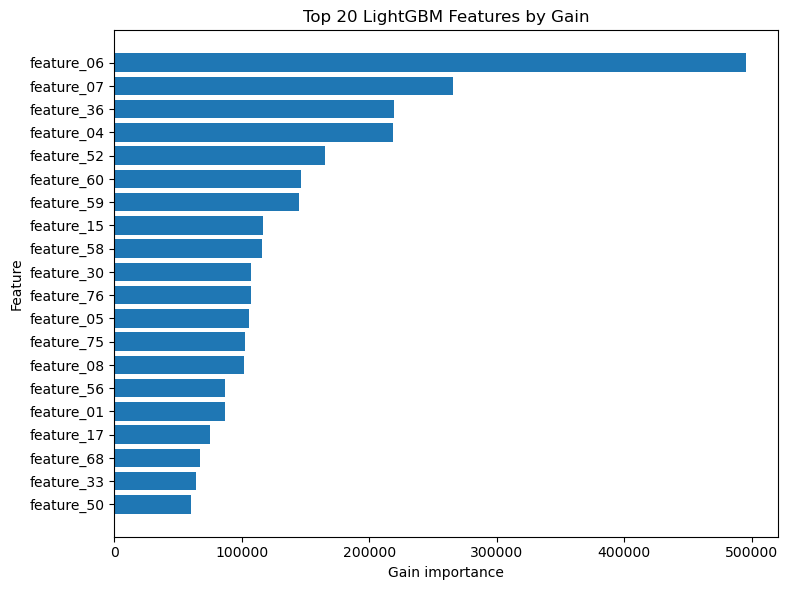

In [18]:
top_n = 20
plot_df = importance_df.head(top_n).sort_values("importance_gain", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance_gain"])
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} LightGBM Features by Gain")
plt.tight_layout()
plt.show()

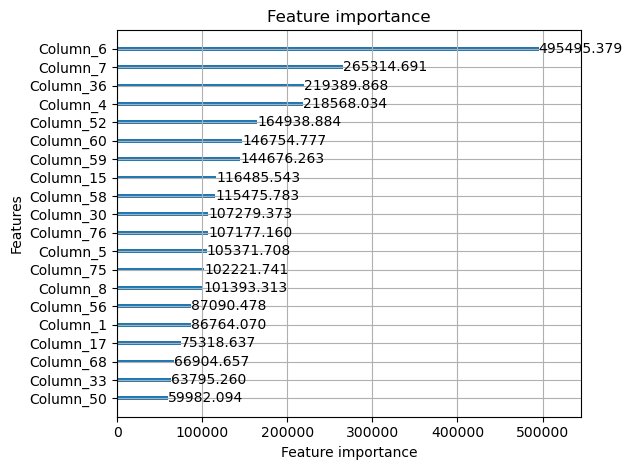

In [19]:
lgb.plot_importance(model, importance_type="gain", max_num_features=20)
plt.tight_layout()
plt.show()

In [11]:
TOP10_ZSCORE_FEATURES = [6, 7, 36, 4, 52, 60, 59, 15, 58, 30]
TOP15_ZSCORE_FEATURES = [6, 7, 36, 4, 52, 60, 59, 15, 58, 30, 76, 5, 75, 8, 56]
TOP10_ZSCORE_BASE_COLS = [f"feature_{j:02d}" for j in TOP10_ZSCORE_FEATURES]
TOP15_ZSCORE_BASE_COLS = [f"feature_{j:02d}" for j in TOP15_ZSCORE_FEATURES]
TOP10_ZSCORE_NEW_COLS = [f"feature_{j:02d}_cs_zscore" for j in TOP10_ZSCORE_FEATURES]
TOP15_ZSCORE_NEW_COLS = [f"feature_{j:02d}_cs_zscore" for j in TOP15_ZSCORE_FEATURES]

FEATURE_COLS_WITH_TOP10_ZSCORE = FEATURE_COLS + TOP10_ZSCORE_NEW_COLS
FEATURE_COLS_WITH_TOP15_ZSCORE = FEATURE_COLS + TOP15_ZSCORE_NEW_COLS

In [ ]:
# def add_cross_sectional_zscore_features(
#     df,
#     zscore_feature_ids=TOP10_ZSCORE_FEATURES,
#     group_cols=(DATE_COL, TIME_COL),
# ):

#     base_cols = [f"feature_{j:02d}" for j in zscore_feature_ids]
#     mean_exprs = [
#         pl.col(c).mean().over(list(group_cols)).alias(f"{c}__cs_mean_tmp")
#         for c in base_cols
#     ]
#     std_exprs = [
#         pl.col(c).std().over(list(group_cols)).alias(f"{c}__cs_std_tmp")
#         for c in base_cols
#     ]

#     df = df.with_columns(mean_exprs + std_exprs)

#     zscore_exprs = [
#         (
#             pl.when(
#                 pl.col(f"{c}__cs_std_tmp").is_not_null() &
#                 (pl.col(f"{c}__cs_std_tmp") > 0)
#             )
#             .then(
#                 (pl.col(c) - pl.col(f"{c}__cs_mean_tmp")) / pl.col(f"{c}__cs_std_tmp")
#             )
#             .otherwise(0.0)
#             .cast(pl.Float32)
#             .alias(f"{c}_cs_zscore")
#         )
#         for c in base_cols
#     ]

#     df = df.with_columns(zscore_exprs)

#     tmp_cols = (
#         [f"{c}__cs_mean_tmp" for c in base_cols] +
#         [f"{c}__cs_std_tmp" for c in base_cols]
#     )

#     df = df.drop(tmp_cols)
#     return df

In [12]:
def add_cross_sectional_zscore_features(
    df,
    zscore_feature_ids=TOP10_ZSCORE_FEATURES,
    group_cols=(DATE_COL, TIME_COL),
):
    """
    Robust version:
    1) group_by(date_id, time_id) to compute mean/std
    2) join stats back to original df
    3) compute z-score safely
    """
    base_cols = [f"feature_{j:02d}" for j in zscore_feature_ids]

    # 1. group-level statistics
    agg_exprs = []
    for c in base_cols:
        agg_exprs.append(pl.col(c).mean().alias(f"{c}__cs_mean_tmp"))
        agg_exprs.append(pl.col(c).std().alias(f"{c}__cs_std_tmp"))

    stats_df = (
        df.group_by(list(group_cols))
          .agg(agg_exprs)
    )

    # 2. join back to original df
    df = df.join(stats_df, on=list(group_cols), how="left")

    # 3. z-score
    zscore_exprs = []
    for c in base_cols:
        z_expr = (
            pl.when(
                pl.col(f"{c}__cs_std_tmp").is_not_null() &
                (pl.col(f"{c}__cs_std_tmp") > 0)
            )
            .then(
                (pl.col(c) - pl.col(f"{c}__cs_mean_tmp")) / pl.col(f"{c}__cs_std_tmp")
            )
            .otherwise(0.0)
            .cast(pl.Float32)
            .alias(f"{c}_cs_zscore")
        )
        zscore_exprs.append(z_expr)

    df = df.with_columns(zscore_exprs)

    # 4. drop temporary columns
    tmp_cols = (
        [f"{c}__cs_mean_tmp" for c in base_cols] +
        [f"{c}__cs_std_tmp" for c in base_cols]
    )
    df = df.drop(tmp_cols)

    return df

In [13]:
def prepare_xywd_top10_zscore(
    df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    weight_col=WEIGHT_COL,
    date_col=DATE_COL,
):
    
    df = df.filter(pl.col(target_col).is_not_null())
    
    df = add_cross_sectional_zscore_features(
        df,
        zscore_feature_ids=TOP10_ZSCORE_FEATURES,
        group_cols=(DATE_COL, TIME_COL),
    )

    all_feature_cols = feature_cols + TOP10_ZSCORE_NEW_COLS

    numeric_exprs = [
        pl.col(c).cast(pl.Float32).fill_null(float("nan")).alias(c)
        for c in all_feature_cols
    ]

    X = df.select(numeric_exprs)
    y = df.get_column(target_col).cast(pl.Float32).to_numpy()
    w = df.get_column(weight_col).fill_null(0.0).cast(pl.Float32).to_numpy()
    d = df.get_column(date_col).to_numpy()

    return X, y, w, d

In [14]:
def prepare_xywd_top15_zscore(
    df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    weight_col=WEIGHT_COL,
    date_col=DATE_COL,
):
    
    df = df.filter(pl.col(target_col).is_not_null())
    
    df = add_cross_sectional_zscore_features(
        df,
        zscore_feature_ids=TOP15_ZSCORE_FEATURES,
        group_cols=(DATE_COL, TIME_COL),
    )

    all_feature_cols = feature_cols + TOP15_ZSCORE_NEW_COLS

    numeric_exprs = [
        pl.col(c).cast(pl.Float32).fill_null(float("nan")).alias(c)
        for c in all_feature_cols
    ]

    X = df.select(numeric_exprs)
    y = df.get_column(target_col).cast(pl.Float32).to_numpy()
    w = df.get_column(weight_col).fill_null(0.0).cast(pl.Float32).to_numpy()
    d = df.get_column(date_col).to_numpy()

    return X, y, w, d

In [15]:
def tune_lgbm_holdout_top10_zscore(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.05,
    use_time_decay=True,
    lgb_params=None,
    seed=42,
    time_weight_min=0.5,
    time_weight_max=1.5,
):
    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "min_data_in_leaf": 500,
            "feature_fraction": 0.6,
            "bagging_fraction": 1.0,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 232,
            "n_jobs": -1,
        }

    print("\n" + "=" * 80)
    print(f"Top10-zscore holdout - Train partitions: {list(train_partitions)}")
    print(f"Top10-zscore holdout - Validation partition: {val_partition}")

    train_df = load_partitions(
        train_partitions,
        sample_frac=train_sample_frac,
        seed=seed,
    )

    val_df = load_partitions(
        [val_partition],
        sample_frac=1.0,
        seed=seed,
    )

    X_train, y_train, w_train_base, d_train = prepare_xywd_top10_zscore(train_df)
    X_val, y_val, w_val, d_val = prepare_xywd_top10_zscore(val_df)

    if use_time_decay:
        w_time = build_time_decay_weights(
            d_train,
            min_multiplier=time_weight_min,
            max_multiplier=time_weight_max,
        )
        w_train = w_train_base * w_time
    else:
        w_train = w_train_base

    print("Training LightGBM for top10-zscore holdout tuning ...")
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, sample_weight=w_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
    val_r2 = official_weighted_r2(y_val, pred_val, w_val)

    print(
        f"Top10-zscore holdout train_r2={train_r2:.6f} "
        f"holdout val_r2={val_r2:.6f}"
    )

    result = {
        "train_rows": len(y_train),
        "val_rows": len(y_val),
        "train_official_r2": train_r2,
        "val_official_r2": val_r2,
    }

    del train_df, val_df, X_train, y_train, w_train_base, d_train, w_train
    del X_val, y_val, w_val, d_val, pred_train, pred_val, model
    gc.collect()

    return result

In [16]:
def tune_lgbm_holdout_top15_zscore(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.05,
    use_time_decay=True,
    lgb_params=None,
    seed=42,
    time_weight_min=0.5,
    time_weight_max=1.5,
):
    if lgb_params is None:
        lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "min_data_in_leaf": 500,
            "feature_fraction": 0.6,
            "bagging_fraction": 1.0,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 232,
            "n_jobs": -1,
        }

    print("\n" + "=" * 80)
    print(f"Top15-zscore holdout - Train partitions: {list(train_partitions)}")
    print(f"Top15-zscore holdout - Validation partition: {val_partition}")

    train_df = load_partitions(
        train_partitions,
        sample_frac=train_sample_frac,
        seed=seed,
    )

    val_df = load_partitions(
        [val_partition],
        sample_frac=1.0,
        seed=seed,
    )

    X_train, y_train, w_train_base, d_train = prepare_xywd_top15_zscore(train_df)
    X_val, y_val, w_val, d_val = prepare_xywd_top15_zscore(val_df)

    if use_time_decay:
        w_time = build_time_decay_weights(
            d_train,
            min_multiplier=time_weight_min,
            max_multiplier=time_weight_max,
        )
        w_train = w_train_base * w_time
    else:
        w_train = w_train_base

    print("Training LightGBM for top15-zscore holdout tuning ...")
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train, sample_weight=w_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
    val_r2 = official_weighted_r2(y_val, pred_val, w_val)

    print(
        f"Top15-zscore holdout train_r2={train_r2:.6f} "
        f"holdout val_r2={val_r2:.6f}"
    )

    result = {
        "train_rows": len(y_train),
        "val_rows": len(y_val),
        "train_official_r2": train_r2,
        "val_official_r2": val_r2,
    }

    del train_df, val_df, X_train, y_train, w_train_base, d_train, w_train
    del X_val, y_val, w_val, d_val, pred_train, pred_val, model
    gc.collect()

    return result

In [18]:
final_lgb_params = {
    "objective": "regression",
    "metric": "l2",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,     
    "num_leaves": 31,          
    "max_depth": 5,            
    "min_data_in_leaf": 500,   
    "feature_fraction": 0.6,
    "bagging_fraction": 1.0,
    "bagging_freq": 1,
    "lambda_l2": 5.0,
    "verbosity": -1,
    "random_state": DEFAULT_RANDOM_SEED,
    "n_estimators": 232,       
    "n_jobs": -1,
}

In [19]:
baseline_result = tune_lgbm_holdout(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.3,
    use_time_decay=True,
    lgb_params=final_lgb_params,
    seed=DEFAULT_RANDOM_SEED,
)
print("Baseline:", baseline_result)


Tuning holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Tuning holdout - Validation partition: 9
Training LightGBM for holdout tuning ...
Holdout train_r2=0.020768 holdout val_r2=0.008058
Baseline: {'train_rows': 12255147, 'val_rows': 6274576, 'train_official_r2': 0.02076800322117822, 'val_official_r2': 0.008057803213395776}


In [20]:
top10_result = tune_lgbm_holdout_top10_zscore(
    train_partitions=range(0, 9),
    val_partition=9,
    train_sample_frac=0.3,
    use_time_decay=True,
    lgb_params=final_lgb_params,
    seed=DEFAULT_RANDOM_SEED,
)
print("Top10 zscore:", top10_result)


Top10-zscore holdout - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Top10-zscore holdout - Validation partition: 9
Training LightGBM for top10-zscore holdout tuning ...
Top10-zscore holdout train_r2=0.021109 holdout val_r2=0.008487
Top10 zscore: {'train_rows': 12255147, 'val_rows': 6274576, 'train_official_r2': 0.021109088753306082, 'val_official_r2': 0.008487133412998449}


In [14]:
def expanding_window_lgbm_backtest_top10_zscore(
    reference_rows,
    start_train_partition=0,
    start_val_partition=1,
    end_val_partition=9,
    train_sample_frac=0.3,
    use_time_decay=True,
    base_lgb_params=None,
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
):

    if base_lgb_params is None:
        base_lgb_params = {
            "objective": "regression",
            "metric": "l2",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 31,          
            "max_depth": 5,            
            "min_data_in_leaf": 500,   
            "feature_fraction": 0.6,
            "bagging_fraction": 1.0,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "verbosity": -1,
            "random_state": seed,
            "n_estimators": 232,
            "n_jobs": -1,
        }

    records = []

    for val_pid in tqdm(
        range(start_val_partition, end_val_partition + 1),
        desc="Top10-zscore fair backtest folds",
        leave=False,
    ):
        train_pids = list(range(start_train_partition, val_pid))

        print("\n" + "=" * 80)
        print(f"Top10-zscore fair - Train partitions: {train_pids}")
        print(f"Top10-zscore fair - Validation partition: {val_pid}")

        # 1) load data
        train_df = load_partitions(
            train_pids,
            sample_frac=train_sample_frac,
            seed=seed,
        )

        val_df = load_partitions(
            [val_pid],
            sample_frac=1.0,
            seed=seed,
        )

        # 2) prepare data using top10 zscore features
        X_train, y_train, w_train_base, d_train = prepare_xywd_top10_zscore(train_df)
        X_val, y_val, w_val, d_val = prepare_xywd_top10_zscore(val_df)

        current_rows = len(y_train)

        # 3) same dynamic min_data_in_leaf logic as baseline
        min_data_in_leaf_used = dynamic_min_data_in_leaf_from_rows(
            current_rows=current_rows,
            reference_rows=reference_rows,
            base_min_data_in_leaf=base_lgb_params["min_data_in_leaf"],
            min_min_data_in_leaf=min_min_data_in_leaf,
        )

        params_fold = copy.deepcopy(base_lgb_params)
        params_fold["min_data_in_leaf"] = min_data_in_leaf_used

        # 4) time-decay weights
        if use_time_decay:
            w_time = build_time_decay_weights(
                d_train,
                min_multiplier=time_weight_min,
                max_multiplier=time_weight_max,
            )
            w_train = w_train_base * w_time
        else:
            w_train = w_train_base

        print(
            "Training LightGBM for fair top10-zscore backtest: "
            f"num_leaves={params_fold['num_leaves']}, "
            f"max_depth={params_fold['max_depth']}, "
            f"min_data_in_leaf={params_fold['min_data_in_leaf']}, "
            f"n_estimators={params_fold['n_estimators']}, "
            f"learning_rate={params_fold['learning_rate']}"
        )

        # 5) train model
        model = lgb.LGBMRegressor(**params_fold)
        model.fit(X_train, y_train, sample_weight=w_train)

        # 6) predict
        pred_train = model.predict(X_train)
        pred_val = model.predict(X_val)

        # 7) evaluate
        train_r2 = official_weighted_r2(y_train, pred_train, w_train_base)
        val_r2 = official_weighted_r2(y_val, pred_val, w_val)

        records.append(
            {
                "train_partitions": str(train_pids),
                "val_partition": val_pid,
                "train_rows": current_rows,
                "val_rows": len(y_val),
                "num_leaves_used": params_fold["num_leaves"],
                "min_data_in_leaf_used": params_fold["min_data_in_leaf"],
                "n_estimators_used": params_fold["n_estimators"],
                "learning_rate_used": params_fold["learning_rate"],
                "train_official_r2": train_r2,
                "val_official_r2": val_r2,
                "train_sample_frac": train_sample_frac,
            }
        )

        print(
            f"Top10-zscore fair fold {val_pid}: "
            f"train_r2={train_r2:.6f}, "
            f"val_r2={val_r2:.6f}"
        )

        del train_df, val_df, X_train, X_val, y_train, y_val
        del w_train_base, w_val, d_train, d_val, w_train
        del pred_train, pred_val, model
        gc.collect()

    return pd.DataFrame(records)

##############################

In [20]:
top10_fair_df = expanding_window_lgbm_backtest_top10_zscore(
    reference_rows=816349,
    start_train_partition=0,
    start_val_partition=1,
    end_val_partition=7,
    train_sample_frac=0.3,
    use_time_decay=True,
    base_lgb_params=None,  
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
)

display(top10_fair_df)
print("Mean train official R2:", top10_fair_df["train_official_r2"].mean())
print("Mean validation official R2:", top10_fair_df["val_official_r2"].mean())

Top10-zscore fair backtest folds:   0%|          | 0/7 [00:00<?, ?it/s]


Top10-zscore fair - Train partitions: [0]
Top10-zscore fair - Validation partition: 1
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=423, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 1: train_r2=0.057437, val_r2=0.010355

Top10-zscore fair - Train partitions: [0, 1]
Top10-zscore fair - Validation partition: 2
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=660, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 2: train_r2=0.035265, val_r2=0.012140

Top10-zscore fair - Train partitions: [0, 1, 2]
Top10-zscore fair - Validation partition: 3
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=846, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 3: train_r2=0.028531, val_r2=0.009822

Top10-zscore fair - Train partitions: [0, 1, 2, 3]
Top10-zscore fair - Validation partition: 4
Training LightGBM for fair top10-zscore 

,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,[0],1,583184,2804247,31,423,232,0.05,0.057437,0.010355,0.3
1,"[0, 1]",2,1424432,3036873,31,660,232,0.05,0.035265,0.012140,0.3
2,"[0, 1, 2]",3,2335470,4016784,31,846,232,0.05,0.028531,0.009822,0.3
3,"[0, 1, 2, 3]",4,3540402,5022952,31,1041,232,0.05,0.024696,0.017461,0.3
4,"[0, 1, 2, 3, 4]",5,5047177,5348200,31,1243,232,0.05,0.025373,0.014152,0.3
5,"[0, 1, 2, 3, 4, 5]",6,6651561,6203912,31,1427,232,0.05,0.023255,0.011312,0.3
6,"[0, 1, 2, 3, 4, 5, 6]",7,8512641,6335560,31,1615,232,0.05,0.021224,0.010258,0.3


Mean train official R2: 0.03082569264609006
Mean validation official R2: 0.012214112821944068


In [19]:
top10_fair_df = expanding_window_lgbm_backtest_top10_zscore(
    reference_rows=816349,
    start_train_partition=0,
    start_val_partition=7,
    end_val_partition=7,
    train_sample_frac=0.3,
    use_time_decay=True,
    base_lgb_params=None,  
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
)

display(top10_fair_df)
print("Mean train official R2:", top10_fair_df["train_official_r2"].mean())
print("Mean validation official R2:", top10_fair_df["val_official_r2"].mean())

Top10-zscore fair backtest folds:   0%|          | 0/1 [00:00<?, ?it/s]


Top10-zscore fair - Train partitions: [0, 1, 2, 3, 4, 5, 6]
Top10-zscore fair - Validation partition: 7
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=1615, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 7: train_r2=0.021224, val_r2=0.010259


,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,"[0, 1, 2, 3, 4, 5, 6]",7,8512641,6335560,31,1615,232,0.05,0.021224,0.010259,0.3


Mean train official R2: 0.021223717328313185
Mean validation official R2: 0.010259038548351085


In [18]:
top10_fair_df = expanding_window_lgbm_backtest_top10_zscore(
    reference_rows=816349,
    start_train_partition=0,
    start_val_partition=8,
    end_val_partition=8,
    train_sample_frac=0.3,
    use_time_decay=True,
    base_lgb_params=None,  
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
)

display(top10_fair_df)
print("Mean train official R2:", top10_fair_df["train_official_r2"].mean())
print("Mean validation official R2:", top10_fair_df["val_official_r2"].mean())

Top10-zscore fair backtest folds:   0%|          | 0/1 [00:00<?, ?it/s]


Top10-zscore fair - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7]
Top10-zscore fair - Validation partition: 8
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=1786, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 8: train_r2=0.020000, val_r2=0.015315


,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,"[0, 1, 2, 3, 4, 5, 6, 7]",8,10413220,6140024,31,1786,232,0.05,0.02,0.015315,0.3


Mean train official R2: 0.020000273531573964
Mean validation official R2: 0.015314985984497653


In [17]:
top10_fair_df = expanding_window_lgbm_backtest_top10_zscore(
    reference_rows=816349,
    start_train_partition=0,
    start_val_partition=9,
    end_val_partition=9,
    train_sample_frac=0.3,
    use_time_decay=True,
    base_lgb_params=None,  
    seed=DEFAULT_RANDOM_SEED,
    time_weight_min=0.5,
    time_weight_max=1.5,
    min_min_data_in_leaf=100,
)

display(top10_fair_df)
print("Mean train official R2:", top10_fair_df["train_official_r2"].mean())
print("Mean validation official R2:", top10_fair_df["val_official_r2"].mean())

Top10-zscore fair backtest folds:   0%|          | 0/1 [00:00<?, ?it/s]


Top10-zscore fair - Train partitions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Top10-zscore fair - Validation partition: 9
Training LightGBM for fair top10-zscore backtest: num_leaves=31, max_depth=5, min_data_in_leaf=1937, n_estimators=232, learning_rate=0.05
Top10-zscore fair fold 9: train_r2=0.019930, val_r2=0.008368


,train_partitions,val_partition,train_rows,val_rows,num_leaves_used,min_data_in_leaf_used,n_estimators_used,learning_rate_used,train_official_r2,val_official_r2,train_sample_frac
0,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",9,12255147,6274576,31,1937,232,0.05,0.01993,0.008368,0.3


Mean train official R2: 0.01993011675467682
Mean validation official R2: 0.008367955372675318


In [3]:
np.mean([0.010355, 0.012140, 0.009822, 0.017461, 0.014152, 0.011312, 0.010258, 0.010259, 0.015315, 0.008368	])

0.0119442